# Patching intro: sliding-window inference on a raster

This notebook walks through the canonical `SpatialPatcher` use case —
splitting a raster into chips, running an operator per chip, and stitching
the results back into a global field. It uses a synthetic `GeoTensor` so no
real files are needed. (For the real on-disk version see the
`patching_geotiff_streaming` notebook.)

We track array shapes after every operation so the data flow is explicit.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from georeader.geotensor import GeoTensor

from geotoolz import Sequential
from geotoolz.core import Lambda
from geotoolz.patch import (
    ApplyToChips,
    GridSampler,
    RasterField,
    SpatialBoxcar,
    SpatialCustom,
    SpatialGaussian,
    SpatialHann,
    SpatialOverlapAdd,
    SpatialPatcher,
    SpatialRectangular,
    SpatialRegularStride,
    SpatialTukey,
    Stitch,
)

## A synthetic field

A 64×64 single-band raster with a smooth gradient so patch boundaries are
easy to spot.

arr.shape: (64, 64),  arr.dtype: float32


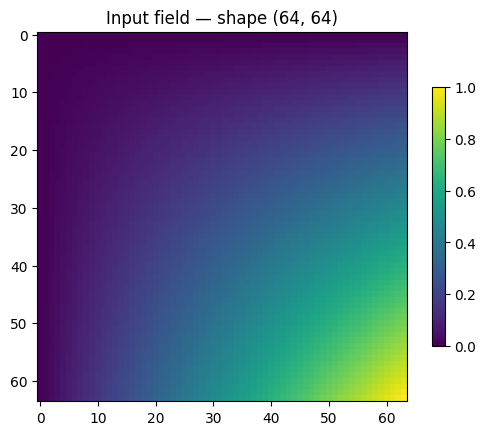

In [2]:
arr = np.outer(np.linspace(0, 1, 64), np.linspace(0, 1, 64)).astype(np.float32)
print(f"arr.shape: {arr.shape},  arr.dtype: {arr.dtype}")  # (64, 64) float32

gt = GeoTensor(values=arr, transform=rasterio.Affine.identity(), crs="EPSG:32630")
field = RasterField(gt)

plt.imshow(arr, cmap="viridis")
plt.title("Input field — shape (64, 64)")
plt.colorbar(shrink=0.7)
plt.show()

## The four-axis Patcher

16×16 `SpatialRectangular` patches, `SpatialRegularStride` of 16
(non-overlapping), `SpatialBoxcar` window (no taper), reconstruct via
`SpatialOverlapAdd`.

In [3]:
patcher = SpatialPatcher(
    geometry=SpatialRectangular(size=(16, 16)),
    sampler=SpatialRegularStride(step=16),
    window=SpatialBoxcar(),
    aggregation=SpatialOverlapAdd(),
)

patches = list(patcher.split(field))
print(f"len(patches): {len(patches)}                              # 4x4 = 16")
print(f"patches[0].data.shape: {np.asarray(patches[0].data).shape}   # (16, 16)")
print(f"patches[0].anchor: {patches[0].anchor}                  # (row, col)")
print(f"patches[0].indices: {patches[0].indices}")

len(patches): 16                              # 4x4 = 16
patches[0].data.shape: (16, 16)   # (16, 16)
patches[0].anchor: (0, 0)                  # (row, col)
patches[0].indices: Window(col_off=0, row_off=0, width=16, height=16)


## A window gallery

Before running an operator, let's compare the five `SpatialWindow` classes.
Each `Window.weights(geometry)` returns an array shaped like the patch — the
multiplier OverlapAdd uses on the way in (per-cell) and the denominator on
the way out (sum-of-weights).

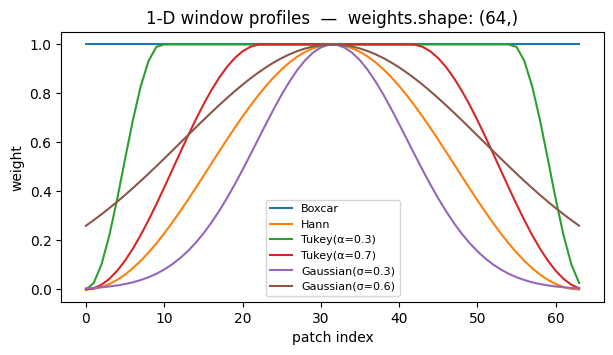

          Boxcar: weights.shape: (32, 32)
            Hann: weights.shape: (32, 32)
    Tukey(α=0.5): weights.shape: (32, 32)
 Gaussian(σ=0.4): weights.shape: (32, 32)


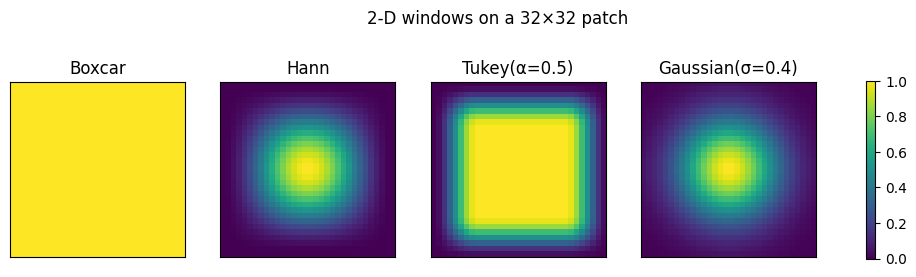

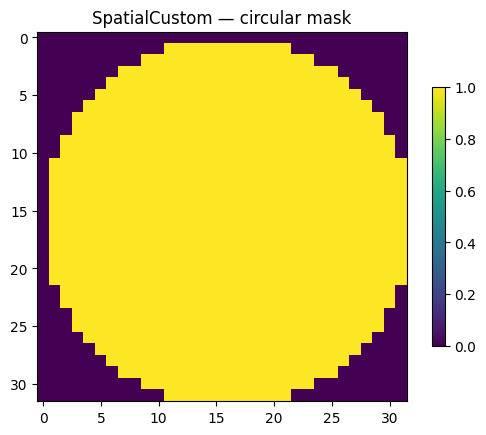

In [4]:
windows_1d = {
    "Boxcar": SpatialBoxcar(),
    "Hann": SpatialHann(),
    "Tukey(α=0.3)": SpatialTukey(alpha=0.3),
    "Tukey(α=0.7)": SpatialTukey(alpha=0.7),
    "Gaussian(σ=0.3)": SpatialGaussian(sigma=0.3),
    "Gaussian(σ=0.6)": SpatialGaussian(sigma=0.6),
}
geom1d = SpatialRectangular(size=(1, 64))  # 1×64 patch — easy to plot
fig, ax = plt.subplots(figsize=(7, 3.5))
for name, w in windows_1d.items():
    weights = w.weights(geom1d).reshape(-1)
    ax.plot(weights, label=name)
ax.set_title("1-D window profiles  —  weights.shape: (64,)")
ax.set_xlabel("patch index")
ax.set_ylabel("weight")
ax.legend(fontsize=8)
plt.show()

# 2-D view — same windows on a 32×32 patch
windows_2d = {
    "Boxcar": SpatialBoxcar(),
    "Hann": SpatialHann(),
    "Tukey(α=0.5)": SpatialTukey(alpha=0.5),
    "Gaussian(σ=0.4)": SpatialGaussian(sigma=0.4),
}
geom2d = SpatialRectangular(size=(32, 32))
fig, axes = plt.subplots(1, 4, figsize=(13, 3.3))
for ax, (name, w) in zip(axes, windows_2d.items(), strict=True):
    weights = w.weights(geom2d)
    print(f"{name:>16s}: weights.shape: {weights.shape}")
    im = ax.imshow(weights, vmin=0, vmax=1, cmap="viridis")
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.7)
plt.suptitle("2-D windows on a 32×32 patch")
plt.show()

# `SpatialCustom` is the escape hatch — pass any callable
ring = SpatialCustom(
    fn=lambda g: (
        ((np.indices(g.size) - np.array(g.size)[:, None, None] / 2) ** 2).sum(axis=0)
        < (g.size[0] / 2) ** 2
    )
)
plt.imshow(ring.weights(geom2d), cmap="viridis")
plt.title("SpatialCustom — circular mask")
plt.colorbar(shrink=0.7)
plt.show()

## Per-chip operator: invert

A tiny operator that flips the gradient inside each chip.

len(out_patches): 16
out_patches[0].data.shape: (16, 16)     # (16, 16)
stitched.shape: (64, 64)                           # (64, 64)


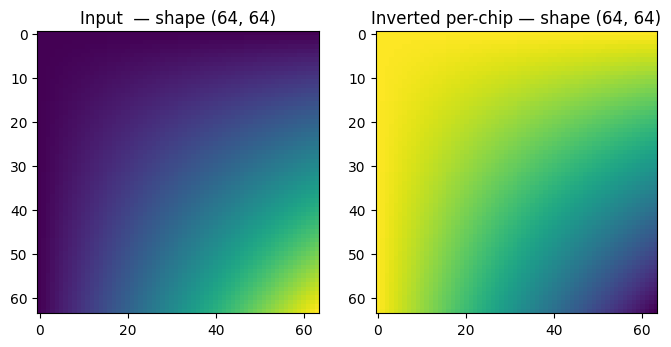

In [5]:
invert = Lambda(lambda gt: 1.0 - np.asarray(gt), name="invert")

out_patches = ApplyToChips(invert)(patches)
print(f"len(out_patches): {len(out_patches)}")
print(f"out_patches[0].data.shape: {out_patches[0].data.shape}     # (16, 16)")

stitched = patcher.aggregation.merge(out_patches, field.reader)
print(f"stitched.shape: {stitched.shape}                           # (64, 64)")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(np.asarray(field.reader), cmap="viridis")
axes[0].set_title(f"Input  — shape {arr.shape}")
axes[1].imshow(stitched, cmap="viridis")
axes[1].set_title(f"Inverted per-chip — shape {stitched.shape}")
plt.show()

## Composition with `Sequential`

Same loop, expressed as a 3-operator linear pipeline using the operator
wrappers. This is how the Patcher fits into the broader algebra.

In [6]:
pipe = Sequential(
    [
        GridSampler(patcher),
        ApplyToChips(invert),
        Stitch(SpatialOverlapAdd(), domain=field.reader),
    ]
)
result = pipe(field)
print(f"result.shape: {result.shape}                               # (64, 64)")
np.testing.assert_allclose(result, stitched)
print("`Sequential` and the manual loop produce identical output")

result.shape: (64, 64)                               # (64, 64)
`Sequential` and the manual loop produce identical output


## Hann window + overlap

Swap to a Hann window with stride < patch size. The OverlapAdd aggregation
now normalises by the accumulated weights so the seams blend cleanly.

out2.shape: (64, 64)                                   # (64, 64)


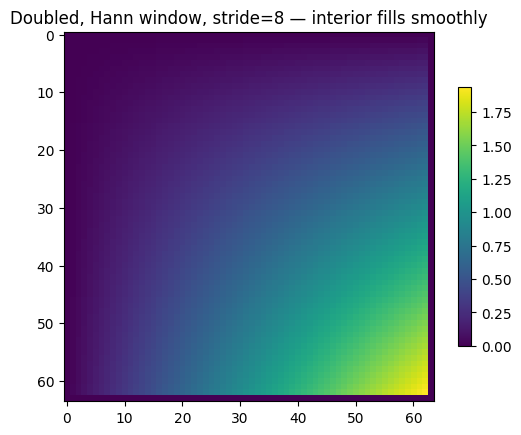

In [7]:
overlap_patcher = SpatialPatcher(
    geometry=SpatialRectangular(size=(16, 16)),
    sampler=SpatialRegularStride(step=8),  # half the patch size
    window=SpatialHann(),
    aggregation=SpatialOverlapAdd(),
)
double = Lambda(lambda gt: np.asarray(gt) * 2.0, name="double")

pipe2 = Sequential(
    [
        GridSampler(overlap_patcher),
        ApplyToChips(double),
        Stitch(SpatialOverlapAdd(), domain=field.reader),
    ]
)
out2 = pipe2(field)
print(f"out2.shape: {out2.shape}                                   # (64, 64)")

plt.imshow(out2, cmap="viridis")
plt.title("Doubled, Hann window, stride=8 — interior fills smoothly")
plt.colorbar(shrink=0.7)
plt.show()

## `get_config()` round-trip

Every axis (and the Patcher itself) returns a JSON-serialisable
`get_config()` dict — the audit-trail artifact that lets you persist a
pipeline as YAML or hash it for regulatory reproducibility.

In [8]:
import json


print(json.dumps(patcher.get_config(), indent=2))

{
  "geometry": {
    "class": "SpatialRectangular",
    "config": {
      "size": [
        16,
        16
      ]
    }
  },
  "sampler": {
    "class": "SpatialRegularStride",
    "config": {
      "step": 16
    }
  },
  "window": {
    "class": "SpatialBoxcar",
    "config": {}
  },
  "aggregation": {
    "class": "SpatialOverlapAdd",
    "config": {
      "streaming": false,
      "target_path": null,
      "chunks": null,
      "normalize_by_window": true
    }
  }
}
